# Two nonlinear sensors → inverse sensor model as a LUT → fusion

Goals:
1. Simulate two sensors with nonlinear response curves, different bias, and Gaussian noise
2. Visualize both response curves
3. Build a separate *inverse* sensor model (ISM) as a look-up table (LUT) from samples for each sensor
4. Use the LUT-ISMs to perform sensor fusion (weighted mean)

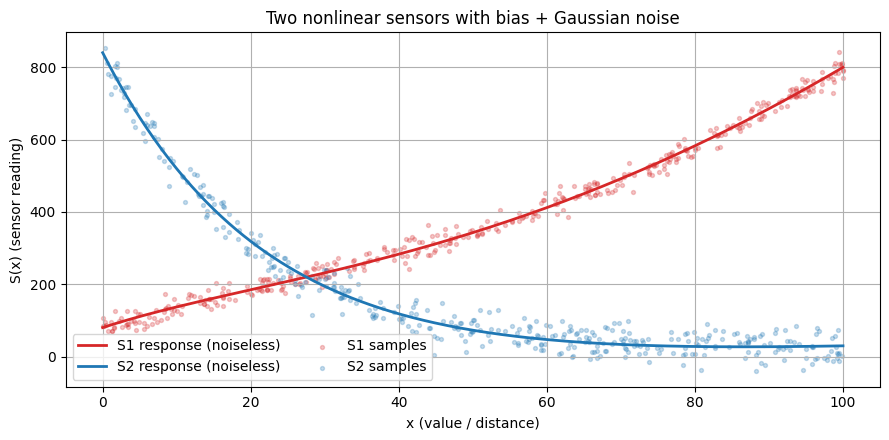

In [16]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


def s1_forward(x: np.ndarray) -> np.ndarray:
    """Nonlinear, monotonically increasing response curve."""
    x = np.asarray(x)
    return 120.0 * (1.0 - np.exp(-x / 18.0)) + 0.06 * x**2


def s2_forward(x: np.ndarray) -> np.ndarray:
    """Nonlinear, monotonically decreasing response curve."""
    x = np.asarray(x)
    return 900.0 * np.exp(-x / 22.0) + 0.8 * x


class NonlinearSensor:
    def __init__(self, name: str, forward_fn, bias: float, sigma: float):
        self.name = name
        self.forward_fn = forward_fn
        self.bias = float(bias)
        self.sigma = float(sigma)

    def sample(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x)
        noise = rng.normal(loc=0.0, scale=self.sigma, size=x.shape)
        return self.forward_fn(x) + self.bias + noise

    def calibration_samples(self, n: int, x_min: float, x_max: float):
        x = rng.uniform(x_min, x_max, size=n)
        s = self.sample(x)
        return x, s


# 1) Define sensors (different bias + noise)
x_min, x_max = 0.0, 100.0
sensor1 = NonlinearSensor(name="S1", forward_fn=s1_forward, bias=+80.0, sigma=18.0)
sensor2 = NonlinearSensor(name="S2", forward_fn=s2_forward, bias=-60.0, sigma=30.0)

# 2) Visualize response curves (noiseless curve + noisy samples)
x_grid = np.linspace(x_min, x_max, 400)

n_calib = 4000
x1_cal, s1_cal = sensor1.calibration_samples(n=n_calib, x_min=x_min, x_max=x_max)
x2_cal, s2_cal = sensor2.calibration_samples(n=n_calib, x_min=x_min, x_max=x_max)

plt.figure(figsize=(9, 4.5))
plt.plot(x_grid, s1_forward(x_grid) + sensor1.bias, color="tab:red", lw=2, label="S1 response (noiseless)")
plt.plot(x_grid, s2_forward(x_grid) + sensor2.bias, color="tab:blue", lw=2, label="S2 response (noiseless)")

plt.scatter(x1_cal[::10], s1_cal[::10], s=8, alpha=0.25, color="tab:red", label="S1 samples")
plt.scatter(x2_cal[::10], s2_cal[::10], s=8, alpha=0.25, color="tab:blue", label="S2 samples")

plt.xlabel("x (value / distance)")
plt.ylabel("S(x) (sensor reading)")
plt.title("Two nonlinear sensors with bias + Gaussian noise")
plt.grid(True)
plt.legend(ncols=2)
plt.tight_layout()
plt.show()

In [17]:
sensor1.bias, sensor1.sigma, sensor2.bias, sensor2.sigma

(80.0, 18.0, -60.0, 30.0)

In [18]:
x1_cal

array([77.39560486, 43.88784398, 85.85979199, ..., 45.3191935 ,
       33.96624638, 18.03537216])

In [19]:
s1_cal

array([539.04533897, 278.15067849, 665.64326584, ..., 326.89728942,
       261.38757243, 150.06663029])

In [20]:
x1_cal.shape, s1_cal.shape

((4000,), (4000,))

RMSE(ISMs, dict LUT): S1 ≈ 2.99 x-units, S2 ≈ 13.72 x-units


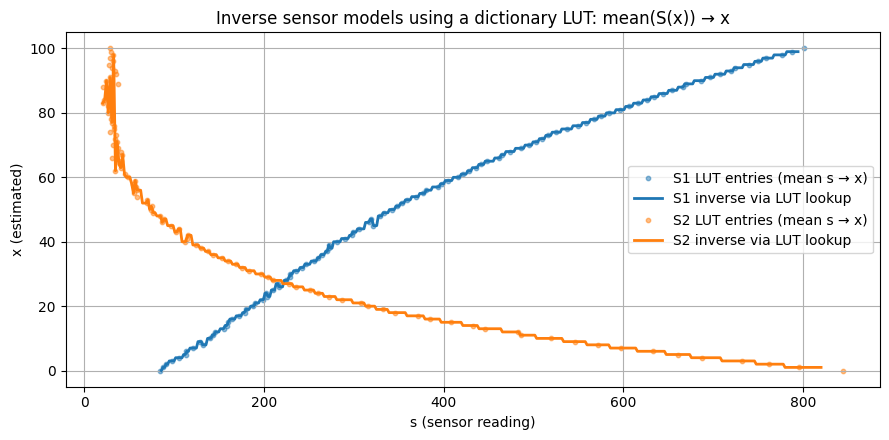

In [21]:
# 3) Inverse Sensor Model (ISM) as a simple dictionary LUT: mean(S(x)) -> x
#
# Build step:
#   For each fixed x, measure the sensor multiple times and store the mean sensor reading.
#   This gives a LUT entry:  mean(S(x))  ->  x
#
# Query step (very simple, easy to follow):
#   Given a measured sensor value s, scan all LUT keys and return the x whose key is closest to s.


def build_lut_mean_s_to_x(sensor: NonlinearSensor, x_values: np.ndarray, n_repeats: int):
    """Return a dict that maps mean sensor reading to x, plus the key/value arrays for plotting."""
    lut = {}
    s_means = []
    x_out = []

    for x in x_values:
        x = float(x)
        s_samples = sensor.sample(np.full(n_repeats, x))
        s_mean = float(np.mean(s_samples))

        # Avoid rare collisions of float keys (keep it simple and deterministic)
        while s_mean in lut:
            s_mean = float(np.nextafter(s_mean, np.inf))

        lut[s_mean] = x
        s_means.append(s_mean)
        x_out.append(x)

    return lut, np.array(s_means, dtype=float), np.array(x_out, dtype=float)


def lut_lookup_nearest(lut: dict, s_query: float):
    """Brute-force nearest-neighbor lookup in the dict (simple for teaching)."""
    best_s_key = None
    best_x = None
    best_dist = float("inf")

    for s_key, x_val in lut.items():
        dist = abs(s_query - s_key)
        if dist < best_dist:
            best_dist = dist
            best_s_key = s_key
            best_x = x_val

    return best_x, best_s_key, best_dist


def lut_predict(lut: dict, s_query: np.ndarray) -> np.ndarray:
    s_query = np.asarray(s_query, dtype=float)
    out = np.empty_like(s_query, dtype=float)

    for i, s in enumerate(s_query):
        out[i] = lut_lookup_nearest(lut, float(s))[0]

    return out


# Build LUTs: use a fixed x-grid and multiple measurements per x
n_repeats = 50
x_lut_grid = np.arange(x_min, x_max + 1.0, 1.0)

lut1, s1_keys, x1_vals = build_lut_mean_s_to_x(sensor1, x_lut_grid, n_repeats=n_repeats)
lut2, s2_keys, x2_vals = build_lut_mean_s_to_x(sensor2, x_lut_grid, n_repeats=n_repeats)

# Quick quality estimate of the inverse models (evaluate on noisy measurements)
n_eval = 800
x_eval = rng.uniform(x_min, x_max, size=n_eval)

s1_eval = sensor1.sample(x_eval)
s2_eval = sensor2.sample(x_eval)

x1_eval_hat = lut_predict(lut1, s1_eval)
x2_eval_hat = lut_predict(lut2, s2_eval)

rmse1 = float(np.sqrt(np.mean((x1_eval_hat - x_eval) ** 2)))
rmse2 = float(np.sqrt(np.mean((x2_eval_hat - x_eval) ** 2)))

print(f"RMSE(ISMs, dict LUT): S1 ≈ {rmse1:.2f} x-units, S2 ≈ {rmse2:.2f} x-units")

# Visualization: inverse curve x(s) computed via LUT lookup

def plot_inverse(sensor_name: str, s_keys: np.ndarray, x_vals: np.ndarray, lut: dict):
    s_lo, s_hi = np.percentile(s_keys, [0.5, 99.5])
    s_grid = np.linspace(s_lo, s_hi, 400)
    x_pred = lut_predict(lut, s_grid)

    plt.scatter(s_keys, x_vals, s=10, alpha=0.5, label=f"{sensor_name} LUT entries (mean s → x)")
    plt.plot(s_grid, x_pred, lw=2, label=f"{sensor_name} inverse via LUT lookup")


plt.figure(figsize=(9, 4.5))
plot_inverse("S1", s1_keys, x1_vals, lut1)
plot_inverse("S2", s2_keys, x2_vals, lut2)
plt.xlabel("s (sensor reading)")
plt.ylabel("x (estimated)")
plt.title("Inverse sensor models using a dictionary LUT: mean(S(x)) → x")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

RMSE (test):
  only S1:  2.73
  only S2:  14.49
  fusion:   2.71


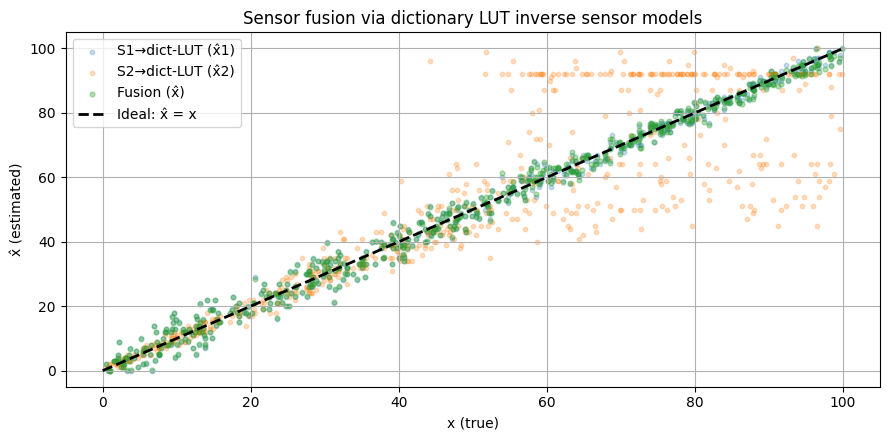

In [14]:
# 4) Fusion: dict-LUT provides x̂1, x̂2; fuse via a weighted mean
#    We use constant weights derived from LUT RMSE (simple and easy to follow).

n_test = 600
x_true = rng.uniform(x_min, x_max, size=n_test)

s1_meas = sensor1.sample(x_true)
s2_meas = sensor2.sample(x_true)

x1_hat = lut_predict(lut1, s1_meas)
x2_hat = lut_predict(lut2, s2_meas)

w1 = 1.0 / (rmse1**2 + 1e-12)
w2 = 1.0 / (rmse2**2 + 1e-12)
x_fused = (w1 * x1_hat + w2 * x2_hat) / (w1 + w2)

err1 = x1_hat - x_true
err2 = x2_hat - x_true
errf = x_fused - x_true

print(
    "RMSE (test):\n"
    f"  only S1:  {np.sqrt(np.mean(err1**2)):.2f}\n"
    f"  only S2:  {np.sqrt(np.mean(err2**2)):.2f}\n"
    f"  fusion:   {np.sqrt(np.mean(errf**2)):.2f}"
)

plt.figure(figsize=(9, 4.5))
plt.scatter(x_true, x1_hat, s=10, alpha=0.25, label="S1→dict-LUT (x̂1)")
plt.scatter(x_true, x2_hat, s=10, alpha=0.25, label="S2→dict-LUT (x̂2)")
plt.scatter(x_true, x_fused, s=12, alpha=0.35, label="Fusion (x̂)")

plt.plot([x_min, x_max], [x_min, x_max], "k--", lw=2, label="Ideal: x̂ = x")
plt.xlabel("x (true)")
plt.ylabel("x̂ (estimated)")
plt.title("Sensor fusion via dictionary LUT inverse sensor models")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Note on the idea (ISM as a dictionary LUT)

- Forward model: $x \rightarrow S(x)$ (response curve + bias + noise)
- For each fixed $x$: measure several times and store the mean sensor reading $\bar{s}(x)$
- Dictionary LUT entry: $\bar{s}(x) \rightarrow x$
- Query: given a measurement $s$, scan all dictionary keys and pick the closest one
- Fusion: combine $\hat{x}_1$ and $\hat{x}_2$ (here: constant weights based on RMSE)

In [15]:
# Small single example
x0 = 10.0
s1_0 = float(sensor1.sample(np.array([x0]))[0])
s2_0 = float(sensor2.sample(np.array([x0]))[0])

x1_0, s1_key, d1 = lut_lookup_nearest(lut1, s1_0)
x2_0, s2_key, d2 = lut_lookup_nearest(lut2, s2_0)
x_f0 = float((w1 * x1_0 + w2 * x2_0) / (w1 + w2))

print(f"x_true={x0:.2f}")
print(f"S1 measures s={s1_0:.2f}  → closest key={s1_key:.2f} (|Δ|={d1:.2f}) → x̂1={x1_0:.2f}")
print(f"S2 measures s={s2_0:.2f}  → closest key={s2_key:.2f} (|Δ|={d2:.2f}) → x̂2={x2_0:.2f}")
print(f"Fusion (weighted): x̂={x_f0:.2f}")

x_true=10.00
S1 measures s=176.73  → closest key=174.16 (|Δ|=2.58) → x̂1=17.00
S2 measures s=517.99  → closest key=527.76 (|Δ|=9.77) → x̂2=10.00
Fusion (weighted): x̂=16.74


In [ ]:
# (Optional) Error distributions as a histogram
plt.figure(figsize=(9, 4.2))
plt.hist(err1, bins=40, alpha=0.5, label="S1→LUT")
plt.hist(err2, bins=40, alpha=0.5, label="S2→LUT")
plt.hist(errf, bins=40, alpha=0.6, label="Fusion")
plt.xlabel("Error x̂ - x")
plt.ylabel("Count")
plt.title("Error distribution: single sensor vs fusion")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()